In [2]:
from dummy_spatialdata import generate_dataset
import dummy_anndata
import spatialdata_plot
import spatialdata as sd

In [3]:
# generate anndata
adata = dummy_anndata.generate_dataset(n_obs=12, n_vars=20)

# generate spatialdata
sdata = generate_dataset(
    images = [
        {'type': 'rgb', 'scale_factors': [2,2,2], 'coordinate_system': 'global'},
        {'type': 'grayscale', 'coordinate_system': 'global'},
    ],
    labels = [
        {'n': 12, 'scale_factors': [2,2,3], 'coordinate_system': 'global'},
        {'n': 12, 'coordinate_system': 'global'},
    ], 
    shapes = [
        {'n': 12, 'type': 'circle', 'coordinate_system': 'global'},
        {'n': 20, 'type': 'circle', 'coordinate_system': 'global'},
    ],
    points = [
        {'n': 500000, 'coordinate_system': 'global'} # NOTE: alter n to get different dataset sizes
    ],
    tables = [
        {'table': adata, 'element': 'shape', 'element_index': 0}
    ],
    coordinate_systems = {
        'global': {'transformations': ['identity'], 'shape': {'x': 2000, 'y': 2000}},
    },
    SEED=13
)

c:\Users\stock\miniconda3\envs\sdata\Lib\site-packages\spatialdata\models\models.py:1206: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


In [4]:
sdata

SpatialData object
├── Images
│     ├── 'image_0': DataTree[cyx] (3, 2000, 2000), (3, 1000, 1000), (3, 500, 500), (3, 250, 250)
│     └── 'image_1': DataTree[cyx] (1, 2000, 2000)
├── Labels
│     ├── 'label_0': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (166, 166)
│     └── 'label_1': DataTree[yx] (2000, 2000)
├── Points
│     └── 'point_0': DataFrame with shape: (<Delayed>, 2) (2D points)
├── Shapes
│     ├── 'shape_0': GeoDataFrame shape: (12, 2) (2D shapes)
│     └── 'shape_1': GeoDataFrame shape: (20, 2) (2D shapes)
└── Tables
      └── 'table_0': AnnData (12, 20)
with coordinate systems:
    ▸ 'global', with elements:
        image_0 (Images), image_1 (Images), label_0 (Labels), label_1 (Labels), point_0 (Points), shape_0 (Shapes), shape_1 (Shapes)

In [5]:
sdata["point_0"]

,x,y
npartitions=1,,
0,float64,float64
499999,...,...


c:\Users\stock\miniconda3\envs\sdata\Lib\site-packages\legacy_api_wrap\__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
c:\Users\stock\miniconda3\envs\sdata\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


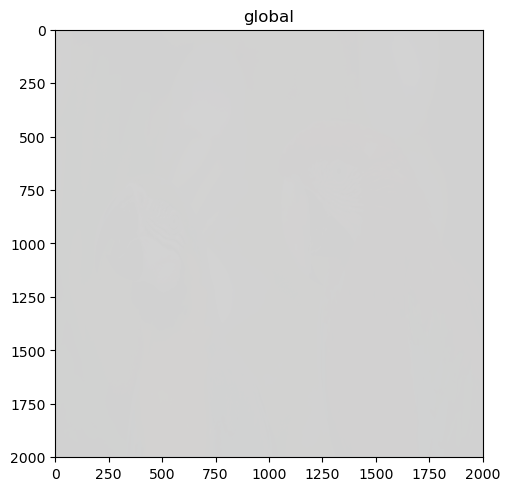

In [8]:
sdata.pl.render_images("image_0").pl.render_points().pl.show()